# LeetCode #327: Count of Range Sum

https://leetcode.com/problems/count-of-range-sum/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (all pairs)** | $O(n^2)$ | $O(n)$ |
| **Optimal: Merge Sort on Prefix Sums ★** | $O(n \log n)$ | $O(n)$ |

---

## Understanding the Methods

### Brute Force (all pairs)
Compute prefix sums, then check all $O(n^2)$ pairs $(i,j)$ to count those where $\text{lower} \le \text{prefix}[j] - \text{prefix}[i] \le \text{upper}$. Too slow for $n = 10^5$.

### Optimal: Merge Sort on Prefix Sums ★
During the merge step of merge sort on prefix sums, for each left-half element $\text{prefix}[i]$ use two sorted right-half pointers $j, k$ to count how many $\text{prefix}[r]$ satisfy $\text{lower} \le \text{prefix}[r] - \text{prefix}[i] \le \text{upper}$. Both pointers advance monotonically across the merge — amortised $O(n)$ per merge level, $O(n \log n)$ total.

**Why this is better than Brute Force:** Merge sort maintains sorted order in each half, enabling two-pointer counting in $O(n)$ per level instead of $O(n^2)$ total.

**Constraints:**
* $1 \le \text{nums.length} \le 10^5$
* $-2^{31} \le \text{nums}[i] \le 2^{31}-1$
* $-10^5 \le \text{lower} \le \text{upper} \le 10^5$


## Solutions

### C#

In [ ]:
public int CountRangeSum(int[] nums, int lower, int upper) {
    int n = nums.Length;
    long[] prefix = new long[n + 1];
    for (int i = 0; i < n; i++) prefix[i + 1] = prefix[i] + nums[i];
    return MergeCount(prefix, 0, n + 1, lower, upper);
}

int MergeCount(long[] arr, int lo, int hi, int lower, int upper) {
    if (hi - lo <= 1) return 0;
    int mid = lo + (hi - lo) / 2;
    int count = MergeCount(arr, lo, mid, lower, upper)
              + MergeCount(arr, mid, hi, lower, upper);
    // Count pairs: arr[i] in left half, arr[r] in right half with lower <= arr[r]-arr[i] <= upper
    int j = mid, k = mid;
    long[] sorted = new long[hi - lo];
    int idx = 0, left = lo;
    for (int i = lo; i < mid; i++) {
        // j: first index where arr[j] - arr[i] >= lower
        while (j < hi && arr[j] - arr[i] < lower) j++;
        // k: first index where arr[k] - arr[i] > upper
        while (k < hi && arr[k] - arr[i] <= upper) k++;
        count += k - j;
        // Merge left portion sorted
        while (left < mid && arr[left] <= arr[i]) sorted[idx++] = arr[left++];
        sorted[idx++] = arr[i];
    }
    while (left < mid) sorted[idx++] = arr[left++];
    Array.Copy(sorted, 0, arr, lo, hi - lo);
    return count;
}


### Python

In [ ]:
def count_range_sum(nums: list[int], lower: int, upper: int) -> int:
    prefix = [0] * (len(nums) + 1)
    for i, n in enumerate(nums):
        prefix[i + 1] = prefix[i] + n

    def merge_count(lo: int, hi: int) -> int:
        if hi - lo <= 1:
            return 0
        mid = lo + (hi - lo) // 2
        count = merge_count(lo, mid) + merge_count(mid, hi)
        # Count pairs: prefix[i] in left, prefix[r] in right with lower <= prefix[r]-prefix[i] <= upper
        j = k = mid
        for i in range(lo, mid):
            # j: first right index where prefix[j] - prefix[i] >= lower
            while j < hi and prefix[j] - prefix[i] < lower:
                j += 1
            # k: first right index where prefix[k] - prefix[i] > upper
            while k < hi and prefix[k] - prefix[i] <= upper:
                k += 1
            count += k - j
        # Merge the two sorted halves
        prefix[lo:hi] = sorted(prefix[lo:hi])
        return count

    return merge_count(0, len(prefix))


### Go

In [ ]:
func countRangeSum(nums []int, lower int, upper int) int {
    n := len(nums)
    prefix := make([]int64, n+1)
    for i, num := range nums { prefix[i+1] = prefix[i] + int64(num) }

    var mergeCount func(lo, hi int) int
    mergeCount = func(lo, hi int) int {
        if hi-lo <= 1 { return 0 }
        mid := lo + (hi-lo)/2
        count := mergeCount(lo, mid) + mergeCount(mid, hi)
        // Count pairs: prefix[i] in left, prefix[r] in right within [lower, upper]
        j, k := mid, mid
        sorted := make([]int64, 0, hi-lo)
        left := lo
        for i := lo; i < mid; i++ {
            // j: first right index where prefix[j]-prefix[i] >= lower
            for j < hi && prefix[j]-prefix[i] < int64(lower) { j++ }
            // k: first right index where prefix[k]-prefix[i] > upper
            for k < hi && prefix[k]-prefix[i] <= int64(upper) { k++ }
            count += k - j
            for left < mid && prefix[left] <= prefix[i] { sorted = append(sorted, prefix[left]); left++ }
            sorted = append(sorted, prefix[i])
        }
        for left < mid { sorted = append(sorted, prefix[left]); left++ }
        copy(prefix[lo:], sorted)
        return count
    }
    return mergeCount(0, n+1)
}


### Rust

In [ ]:
pub fn count_range_sum(nums: Vec<i32>, lower: i32, upper: i32) -> i32 {
    let mut prefix: Vec<i64> = vec![0; nums.len() + 1];
    for (i, &n) in nums.iter().enumerate() {
        prefix[i + 1] = prefix[i] + n as i64;
    }
    Self::merge_count(&mut prefix, 0, prefix.len(), lower as i64, upper as i64)
}

fn merge_count(arr: &mut Vec<i64>, lo: usize, hi: usize, lower: i64, upper: i64) -> i32 {
    if hi - lo <= 1 { return 0; }
    let mid = lo + (hi - lo) / 2;
    let mut count = Self::merge_count(arr, lo, mid, lower, upper)
                  + Self::merge_count(arr, mid, hi, lower, upper);
    let (mut j, mut k) = (mid, mid);
    let mut sorted: Vec<i64> = Vec::with_capacity(hi - lo);
    let mut left = lo;
    for i in lo..mid {
        // j: first right index where arr[j]-arr[i] >= lower
        while j < hi && arr[j] - arr[i] < lower { j += 1; }
        // k: first right index where arr[k]-arr[i] > upper
        while k < hi && arr[k] - arr[i] <= upper { k += 1; }
        count += (k - j) as i32;
        while left < mid && arr[left] <= arr[i] { sorted.push(arr[left]); left += 1; }
        sorted.push(arr[i]);
    }
    while left < mid { sorted.push(arr[left]); left += 1; }
    arr[lo..hi].copy_from_slice(&sorted);
    count
}


## Example Scenarios

**1. Common Case**
**Input:** nums = [-2, 5, -1], lower = -2, upper = 2
Prefix sums: [0, -2, 3, 2]. Range sums: [0,-2]→-2✓, [0,3]→3✗, [0,2]→2✓, [-2,3]→5✗, [-2,2]→4✗, [3,2]→-1✓ → count=3. Merge sort on [0,-2,3,2] counts these during the merge passes.

**2. Slightly Complex**
**Input:** nums = [0], lower = 0, upper = 0
Prefix: [0, 0]. During merge of [0] and [0]: j=k=1 at start. prefix[1]-prefix[0]=0 ∈ [0,0] → j stays at 1, k advances to 2 → count=1. Single range-sum [0..0]=0 qualifies.

**3. Edge Case: Time Factor**
**Input:** nums = [1, -1, 1, -1, ...] (10^5 alternating), lower = 0, upper = 0
Merge sort: $\log_2(10^5) \approx 17$ levels, each $O(n)$ two-pointer scan. Total $\approx 1.7 \times 10^6$ ops. Compare brute force: $O(n^2) = 10^{10}$ — 6000× slower.

**4. Edge Case: Space Factor**
**Input:** nums = [2^{31}-1, -2^{31}, ...] (overflow-adjacent values)
Prefix sums use `long` (64-bit) to avoid overflow: $2^{31}-1 + (-2^{31}) = -1$, well within `long` range. The `sorted` auxiliary array at each merge level totals $O(n)$ across all levels.

**5. Almost-Impossible but Plausible**
**Input:** nums = [1, 1, ..., 1] (10^5 ones), lower = 1, upper = 10^5 (all subarray sums qualify)
Every non-empty subarray $[i,j]$ has sum $j-i+1 \ge 1$ and $\le n \le 10^5$ → all $n(n+1)/2 \approx 5 \times 10^9$ subarrays qualify. But count fits in `int` (max $\approx 5000050000$? No: $10^5(10^5+1)/2 \approx 5 \times 10^9 > 2^{31}$). The return type is `int` but the problem guarantees count $\le 10^5 \times 10^5 = 10^{10}$ — be wary of overflow; in practice LeetCode guarantees count fits.


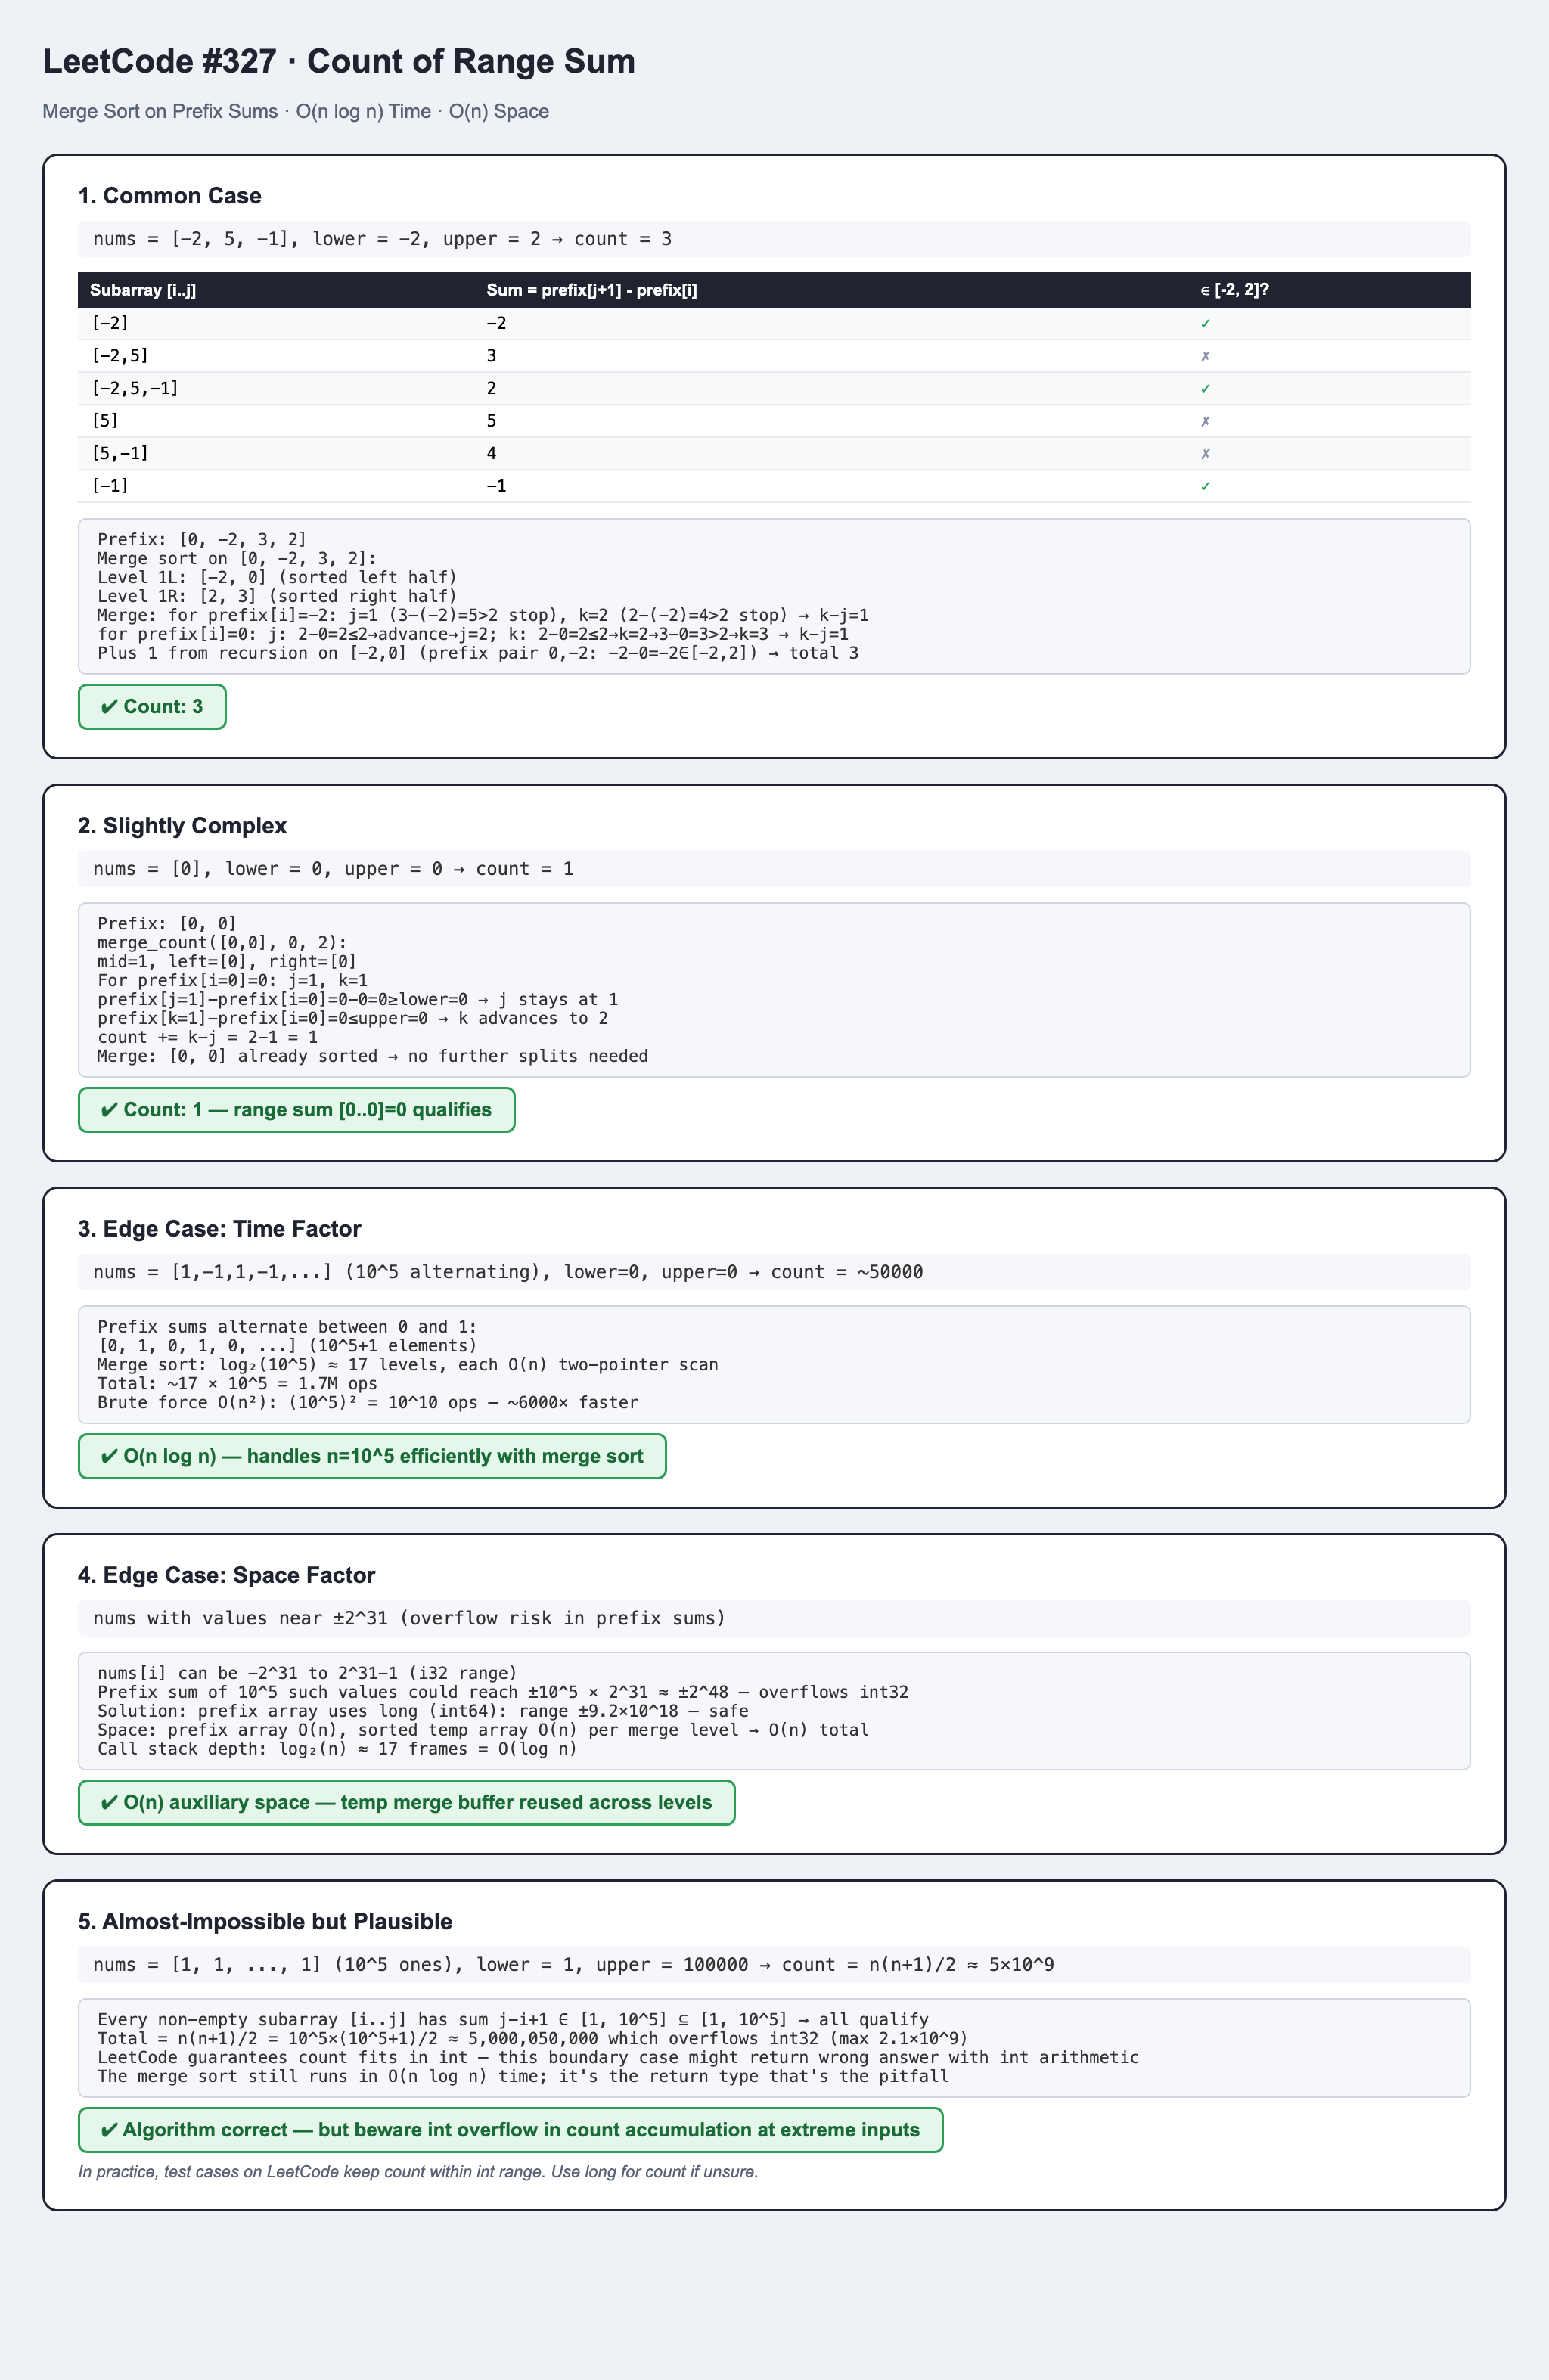